In [1]:
import os
import math
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pickle
import tqdm
%matplotlib inline
from IPython.display import clear_output
from typing import List, Tuple, Optional
import matplotlib.ticker as mticker

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# data_folder = "drive/MyDrive/mestrado_final_files/data/"
# models_token_folder = "drive/MyDrive/mestrado_final_files/models/NGramModel_ExtraInfo/"
# models_token_metrics_folder = "drive/MyDrive/mestrado_final_files/metrics_models/NGramModel_ExtraInfo/"

data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
models_token_folder = "G:\Meu Drive\mestrado_final_files\models\\NGramModel_ExtraInfo\\"
models_token_metrics_folder = "G:\Meu Drive\mestrado_final_files\metrics_models\\NGramModel_ExtraInfo\\"

#models_time_folder = "G:\Meu Drive\mestrado_final_files\models\\SpentTimeModel\\"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
def get_vectorized_murphy(y_true_multiclasse, y_prob_matriz, top_n=600, n_bins=10):
    """
    Calcula as métricas de Murphy de forma vetorizada, corrigindo o
    shape de arrays dinâmicos e espelhando a discretização exata do pd.cut.
    """
    N_amostras = len(y_true_multiclasse)
    if N_amostras == 0:
        return pd.DataFrame()

    # 1. Identificar Top Tokens presentes estritamente neste slice
    tokens, counts = np.unique(y_true_multiclasse, return_counts=True)
    sort_idx = np.argsort(-counts)

    top_tokens_ids = tokens[sort_idx][:top_n]
    top_counts = counts[sort_idx][:top_n]

    # A CORREÇÃO CRÍTICA DO SHAPE:
    actual_n = len(top_tokens_ids)

    # 2. Isolar matrizes para os tokens filtrados
    P = y_prob_matriz[:, top_tokens_ids]
    Y = (y_true_multiclasse[:, None] == top_tokens_ids).astype(float)

    # 3. Taxas Base e Incerteza
    base_rates = Y.mean(axis=0)
    uncertainty = base_rates * (1 - base_rates)

    # 4. Discretização exata equivalente ao pd.cut(include_lowest=True)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    # digitize com right=True aloca valores <= à borda direita do bin
    bins = np.digitize(P, bin_edges[1:], right=True)
    bins = np.clip(bins, 0, n_bins - 1)

    # Vetores dimensionados corretamente para o slice atual
    resolution = np.zeros(actual_n)
    reliability = np.zeros(actual_n)

    for b in range(n_bins):
        mask = (bins == b) # booleano (N_amostras, actual_n)
        bin_counts = mask.sum(axis=0)

        valid = bin_counts > 0

        prob_mean = np.zeros(actual_n)
        # np.where é mais seguro e direto que multiplicar float por bool
        prob_mean[valid] = np.where(mask, P, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        true_fraction = np.zeros(actual_n)
        true_fraction[valid] = np.where(mask, Y, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        weight = bin_counts / N_amostras
        reliability[valid] += weight[valid] * (prob_mean[valid] - true_fraction[valid])**2
        resolution[valid] += weight[valid] * (true_fraction[valid] - base_rates[valid])**2

    brier_score = reliability - resolution + uncertainty

    return pd.DataFrame({
        'token_id': top_tokens_ids,
        'frequencia': top_counts,
        'brier_score_multinomial': brier_score,
        'reliability_erro': reliability,
        'resolution_poder': resolution,
        'uncertainty_caos': uncertainty
    })

def get_vectorized_murphy_all_classes(y_true_multiclasse, y_prob_matriz, classes=None, n_bins=10):
    """
    Calcula a decomposição de Murphy considerando todas as classes possíveis.
    Isso evita perder reliability de classes não observadas no y_true do grupo,
    mas que receberam probabilidade positiva do modelo.
    """
    N_amostras = len(y_true_multiclasse)

    if N_amostras == 0:
        return pd.DataFrame()

    if classes is None:
        classes = np.arange(y_prob_matriz.shape[1])

    classes = np.asarray(classes)

    P = y_prob_matriz[:, classes]
    Y = (y_true_multiclasse[:, None] == classes).astype(float)

    base_rates = Y.mean(axis=0)
    uncertainty = base_rates * (1 - base_rates)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bins = np.digitize(P, bin_edges[1:], right=True)
    bins = np.clip(bins, 0, n_bins - 1)

    actual_n = len(classes)

    resolution = np.zeros(actual_n)
    reliability = np.zeros(actual_n)

    for b in range(n_bins):
        mask = bins == b
        bin_counts = mask.sum(axis=0)

        valid = bin_counts > 0

        prob_mean = np.zeros(actual_n)
        true_fraction = np.zeros(actual_n)

        prob_mean[valid] = np.where(mask, P, 0.0).sum(axis=0)[valid] / bin_counts[valid]
        true_fraction[valid] = np.where(mask, Y, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        weight = bin_counts / N_amostras

        reliability[valid] += weight[valid] * (prob_mean[valid] - true_fraction[valid]) ** 2
        resolution[valid] += weight[valid] * (true_fraction[valid] - base_rates[valid]) ** 2

    brier_decomp = reliability - resolution + uncertainty

    frequencia = Y.sum(axis=0).astype(int)

    return pd.DataFrame({
        "token_id": classes,
        "frequencia": frequencia,
        "brier_score_multinomial": brier_decomp,
        "reliability_erro": reliability,
        "resolution_poder": resolution,
        "uncertainty_caos": uncertainty
    })

In [3]:
with open(data_folder + 'data_token_features.pkl', 'rb') as f:
    df_token_features = pickle.load(f)


In [3]:
tokens_info = pd.read_csv(data_folder + 'tokens_info.txt', sep = ';')\
.sort_values(['cod', 'token'])\
.set_index('token')

# Convert the index of tokens_info to a list of tokens
list_tokens = tokens_info.index.to_list()

# Create a dictionary mapping each token to a unique integer, starting from 1
token_to_integer = {tok: idx + 1 for idx, tok in enumerate(list_tokens)}

# Assign a special integer (0) for the period (.)
token_to_integer['.'] = 0

# Create an inverse mapping from integers back to tokens
integer_to_token = {idx: tok for tok, idx in token_to_integer.items()}

# tokens_info = tokens_info\
# .query("hpts != 0 or vpts != 0 or limhteam != 0 or limvteam != 0")\
# .to_dict(orient = 'index')


In [4]:
%run 01_functions_training.ipynb
#%run drive/MyDrive/mestrado_final_files/notebooks/01_functions_training.ipynb

In [5]:
with open(data_folder + 'dict_set_covariables.pkl', 'rb') as f:
    dict_set_covariables = pickle.load(f)

In [6]:
list_models = [item for item in os.listdir(models_token_folder) if "NGramModel_ExtraInfo_seasondata" in item and ".pth" in item]

In [7]:
VOCAB_SIZE = 601

In [9]:
def get_match_splits(df, num_secs = 300):
    num_breaks = [i for i in range(0, 7201, num_secs)]
    num_labels = [str(i) + "-" + str(j) for i, j in zip(num_breaks[:-1], num_breaks[1:])]
    num_breaks[0] -= 1
    num_breaks[-1] += 1
    return df.assign(cat_time = lambda df: pd.cut(df["remaining_time"], bins = num_breaks, labels = num_labels))

def multiclass_cross_entropy(y_true, y_prob, eps=1e-15):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(np.log(y_prob[np.arange(len(y_true)), y_true]))

def process_group(idx, dev_y, all_probs, classes = None, get_bs_global = False, get_ce = False, get_mae = False):
    y_true_sub = dev_y[idx]
    y_prob_sub = all_probs[idx]

    if classes is None:
        classes = np.arange(y_prob_sub.shape[1])

    df_res = get_vectorized_murphy_all_classes(y_true_multiclasse=y_true_sub, y_prob_matriz = y_prob_sub, classes = classes, n_bins = 10)

    if get_bs_global:
        bs_global = multiclass_brier_score(y_true = y_true_sub, y_prob = y_prob_sub)
        df_res["brier_score_multinomial"] = bs_global

    if get_ce:
        ce_global = multiclass_cross_entropy(y_true = y_true_sub, y_prob = y_prob_sub)
        df_res["cross_entropy"] = ce_global

    if get_mae:
        expected_output = y_prob_sub @ np.arange(y_prob_sub.shape[1])
        mae_global = np.mean(np.abs(y_true_sub - expected_output))
        df_res["mae"] = mae_global

    return df_res

def multiclass_brier_score(y_true, y_prob):
    """
    Calcula o Brier Score Global para classificação multiclasse.
    
    y_true: array 1D com os índices reais dos tokens, shape (N,)
    y_prob: array 2D com as probabilidades preditas (softmax), shape (N, C)
    """
    N_amostras, n_classes = y_prob.shape
    
    # Cria a representação one-hot dos alvos (0.0 para erro, 1.0 para acerto)
    y_true_one_hot = np.zeros_like(y_prob, dtype=float)
    y_true_one_hot[np.arange(N_amostras), y_true] = 1.0
    
    # Calcula o erro quadrático, soma por classe e tira a média por amostra
    brier_score = np.mean(np.sum((y_prob - y_true_one_hot)**2, axis=1))
    
    return brier_score    

In [10]:
def format_time_seconds(x, pos=None):
    x = int(round(x))
    minutes = x // 60
    seconds = x % 60
    return f"{minutes}:{seconds:02d}"



In [12]:
# season = '2018-19'
# # 1. PREPARAÇÃO DOS DADOS DA TEMPORADA (FORA DO LOOP DE MODELOS)
# df_ = df_token_features.query("season == @season").query("season_split == 'dev'")

# # Processamento temporal feito uma única vez por temporada
# df_ = (df_
#         .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))
#         .pipe(get_match_splits, num_secs = 200))

# # Conversão eficiente de memória
# dev_tkn = torch.from_numpy(np.stack(df_["token_features"].values)).to(torch.int64)
# dev_num = torch.from_numpy(np.stack(df_["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
# dev_y = df_["target_tokens"].values

# model_filename = list_models[0]

# CONTEXT_SIZE = int(model_filename.split("_context")[1].split("_")[0])
# EMBEDDING_LAYER_SIZE = int(model_filename.split("_embedding")[1].split("_")[0])
# variables_config = int(model_filename.split("_setcovariables")[1].split("_")[0])
# numerical_input_size = len(dict_set_covariables['index'][variables_config])
# num_hidden_neurons = int(model_filename.split("_numneurons")[1].split("_")[0])
# num_layers = int(model_filename.split("_numlayers")[1].split("_")[0])
# dropout_rate = 0 if "nodropout" in model_filename else int(model_filename.split("_dropout")[1].split("_")[0]) / 10
# layer_norm = True if model_filename.split("_layernorm")[1].split("_")[0] == 'True' else False

# index_covariables = dict_set_covariables["index"][variables_config]

# token_model = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE,
#                                         numerical_input_dim = numerical_input_size, num_hidden_neurons = num_hidden_neurons,
#                                         num_layers = num_layers, activation = nn.GELU, dropout_rate = dropout_rate,
#                                         use_layer_norm = layer_norm)

# token_model.load_state_dict(torch.load(models_token_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
# token_model.eval()

# # 2. INFERÊNCIA
# with torch.no_grad():
#         # Ajuste condicional para modelos que requerem variáveis numéricas
#         output_model = token_model(dev_tkn[:, -CONTEXT_SIZE:], dev_num[:, index_covariables])

#         all_probs = torch.softmax(output_model, dim = 1).cpu().numpy()

In [13]:
# df_ = df_\
# .pipe(get_match_splits, num_breaks = [-1, 50, 200, 300, 7201])

In [14]:
# df_\
# .assign(tp_token = lambda df: df["target_tokens"].map(integer_to_token))\
# .query("tp_token.str.contains('_13')")\
# .groupby(["season", "period", "tp_token"], as_index = False, dropna = False)["remaining_time"].describe(percentiles = [.01, .05, .1, .25, .5, .75, .9, .95, .99])\
# .sort_values(["period", "count"], ascending = [True, False])

In [15]:
# df_\
# .assign(tp_token = lambda df: df["target_tokens"].map(integer_to_token))\
# .query("tp_token.str.contains('_13')")["remaining_time"].plot(kind = "hist", bins = 40, edgecolor = "white")

In [16]:

# # 3. EXTRAÇÃO POR TEMPO
# results_time = []
# for name, group_idx in df_.groupby(["season_split", "period", "cat_time"], observed = True).indices.items():
#     res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs)
#     res_df["season_split"] = name[0]
#     res_df["period"] = name[1]
#     res_df["cat_time"] = name[2]
#     results_time.append(res_df)

In [17]:
# pd.concat(results_time, ignore_index = True)\
# .assign(tp_token = lambda df: df["token_id"].map(integer_to_token))\
# .query("tp_token.str.contains('_13')")\
# .round(4)

### Arquitetura B

In [22]:
list_decomposition_time = []
list_decomposition_dif = []
list_decomposition_time_dif = []
list_decomposition_season = []

group_variables1 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables2 = ["cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables3 = ["period", "cat_time", "cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables4 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]


for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir(models_token_folder) if "NGramModel_ExtraInfo_seasondata" in item and ".pth" in item and str_season in item]

    # 1. PREPARAÇÃO DOS DADOS DA TEMPORADA (FORA DO LOOP DE MODELOS)
    df_ = df_token_features.query("season == @season").query("season_split == 'dev'")

    # Processamento temporal feito uma única vez por temporada
    df_ = df_\
    .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))\
    .pipe(get_match_splits, num_secs = 200)\
    .assign(cat_time = lambda df: df["cat_time"].astype("str"))\
    .assign(cat_dif = lambda df: df["token_state"] % 9)

    # Conversão eficiente de memória
    dev_tkn = torch.from_numpy(np.stack(df_["token_features"].values)).to(torch.int64)
    dev_num = torch.from_numpy(np.stack(df_["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
    dev_y = df_["target_tokens"].values
    dev_mask = torch.tensor(build_logit_mask_ngram_models(df_), dtype = torch.bool, device = device)

    print(season)
    for model_filename in tqdm.tqdm(list_models):

        CONTEXT_SIZE = int(model_filename.split("_context")[1].split("_")[0])
        EMBEDDING_LAYER_SIZE = int(model_filename.split("_embedding")[1].split("_")[0])
        variables_config = int(model_filename.split("_setcovariables")[1].split("_")[0])
        numerical_input_size = len(dict_set_covariables['index'][variables_config])
        num_hidden_neurons = int(model_filename.split("_numneurons")[1].split("_")[0])
        num_layers = int(model_filename.split("_numlayers")[1].split("_")[0])
        dropout_rate = 0 if "nodropout" in model_filename else int(model_filename.split("_dropout")[1].split("_")[0]) / 10
        layer_norm = True if model_filename.split("_layernorm")[1].split("_")[0] == 'True' else False

        index_covariables = dict_set_covariables["index"][variables_config]

        token_model = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE,
                                            numerical_input_dim = numerical_input_size, num_hidden_neurons = num_hidden_neurons,
                                            num_layers = num_layers, activation = nn.GELU, dropout_rate = dropout_rate,
                                            use_layer_norm = layer_norm)

        token_model.load_state_dict(torch.load(models_token_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
        token_model.eval()

        # 2. INFERÊNCIA
        with torch.no_grad():
            # Ajuste condicional para modelos que requerem variáveis numéricas
            if variables_config > 0: # Ajuste esta condição conforme a sua lógica de arquiteturas
                output_model = token_model(dev_tkn[:, -CONTEXT_SIZE:], dev_num[:, index_covariables])
            else:
                output_model = token_model(dev_tkn[:, -CONTEXT_SIZE:])

            output_model = output_model.masked_fill(dev_mask, -1e9)

            all_probs = torch.softmax(output_model, dim = 1).cpu().numpy()

        # 3. EXTRAÇÃO POR TEMPO
        results_time = []
        for name, group_idx in df_.groupby(["season_split", "period", "cat_time"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True)
            res_df["season_split"] = name[0]
            res_df["period"] = name[1]
            res_df["cat_time"] = name[2]
            results_time.append(res_df)

        df_decomposition_by_time = pd.concat(results_time, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_time = df_decomposition_by_time\
        .groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_time[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_time.append(df_resultados_time)

        # 3. EXTRAÇÃO POR DIF
        results_dif = []
        for name, group_idx in df_.groupby(["season_split", "cat_dif"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True)
            res_df["season_split"] = name[0]
            res_df["cat_dif"] = name[1]
            results_dif.append(res_df)

        df_decomposition_by_dif = pd.concat(results_dif, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_dif = df_decomposition_by_dif\
        .groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_dif[group_variables2 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_dif.append(df_resultados_dif)

        # 3. EXTRAÇÃO POR TIME E DIF
        results_time_dif = []
        for name, group_idx in df_.groupby(["season_split", "period", "cat_time", "cat_dif"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True)
            res_df["season_split"] = name[0]
            res_df["period"] = name[1]
            res_df["cat_time"] = name[2]
            res_df["cat_dif"] = name[3]
            results_time_dif.append(res_df)

        df_decomposition_by_time_dif = pd.concat(results_time_dif, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_time_dif = df_decomposition_by_time_dif\
        .groupby(group_variables3 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_time_dif[group_variables3 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_time_dif.append(df_resultados_time_dif)

        # 4. EXTRAÇÃO POR SPLIT
        results_split = []
        for name, group_idx in df_.groupby(["season_split"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True)
            # Como agrupou por apenas 1 coluna, name pode não ser tupla. Usamos diretamente.
            res_df["season_split"] = name
            results_split.append(res_df)

        df_decomposition_by_split = pd.concat(results_split, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)            

        df_resultados_split = df_decomposition_by_split\
        .groupby(group_variables4 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_split[group_variables4 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_season.append(df_resultados_split)


2018-19


100%|██████████| 32/32 [07:44<00:00, 14.51s/it]


2019-20


100%|██████████| 32/32 [07:24<00:00, 13.88s/it]


2020-21


100%|██████████| 32/32 [06:55<00:00, 13.00s/it]


2021-22


100%|██████████| 32/32 [08:12<00:00, 15.40s/it]


2022-23


100%|██████████| 32/32 [07:54<00:00, 14.82s/it]


In [23]:
df_murphy_decomposition_by_time = pd.concat(list_decomposition_time, ignore_index = True)
df_murphy_decomposition_by_time.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time.parquet", index = False, compression = "zstd")

In [24]:
df_murphy_decomposition_by_dif = pd.concat(list_decomposition_dif, ignore_index = True)
df_murphy_decomposition_by_dif.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_dif.parquet", index = False, compression = "zstd")

In [25]:
df_murphy_decomposition_by_time_dif = pd.concat(list_decomposition_time_dif, ignore_index = True)
df_murphy_decomposition_by_time_dif.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_dif.parquet", index = False, compression = "zstd")

In [26]:
df_murphy_decomposition_by_season_split = pd.concat(list_decomposition_season, ignore_index = True)
df_murphy_decomposition_by_season_split.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split.parquet", index = False, compression = "zstd")


In [8]:
list_num_parametros = []
for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir(models_token_folder) if "NGramModel_ExtraInfo_seasondata" in item and ".pkl" in item and str_season in item]

    for file in tqdm.tqdm(list_models):
        with open(models_token_folder + file, "rb") as f:
            resultados_modelo = pickle.load(f)

        list_num_parametros.append((file.replace("results_", ""), resultados_modelo["num_parameters"]))

        

  0%|          | 0/32 [00:00<?, ?it/s]

100%|██████████| 32/32 [00:00<00:00, 54.49it/s]


In [9]:
df_parameters = pd.DataFrame(list_num_parametros, columns = ["modelname", "num_parameters"])

In [10]:
df_parameters\
.assign(seasondata = lambda df: df["modelname"].str.split("_").str[2].str.replace("seasondata", "").astype("int"))\
.assign(context_size = lambda df: df["modelname"].str.split("_").str[3].str.replace("context", "").astype("int"))\
.assign(embedding_layer_size = lambda df: df["modelname"].str.split("_").str[4].str.replace("embedding", "").astype("int"))\
.assign(num_layers = lambda df: df["modelname"].str.split("_").str[5].str.replace("numlayers", "").astype("int"))\
.assign(num_hidden_neurons = lambda df: df["modelname"].str.split("_").str[6].str.replace("numneurons", "").astype("int"))\
.assign(dropout_rate = lambda df: df["modelname"].str.split("_").str[7].str.replace("dropout", "").replace("no", 0).astype("int") / 10)\
.assign(layer_norm = lambda df: df["modelname"].str.split("_").str[8].str.replace("layernorm", ""))\
.assign(set_covariables = lambda df: df["modelname"].str.split("_").str[9].str.replace("setcovariables", "").replace("\.pkl", "", regex = True).astype("int"))\
.drop(columns = "modelname")\
.sort_values("num_parameters")\
.drop_duplicates(["context_size", "embedding_layer_size", "num_layers", "num_hidden_neurons", "layer_norm", "set_covariables"])\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "set_covariables"], columns = ["num_layers", "layer_norm"], values = "num_parameters", aggfunc= lambda x: x)\
.reset_index()

num_layers context_size embedding_layer_size num_hidden_neurons  \
layer_norm                                                        
0                     5                   32                 50   
1                     5                   32                 50   
2                     5                   64                 50   
3                     5                   64                 50   

num_layers set_covariables      3             5         
layer_norm                  False   True  False   True  
0                        1  63833  64385  68933  69685  
1                        2  65033  65633  70133  70933  
2                        1  91065  91937  96165  97237  
3                        2  92265  93185  97365  98485

In [4]:
df_murphy_decomposition_by_season_split = pd.read_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split.parquet")

In [5]:
group_variables1 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

In [6]:
df_resultados1 = df_murphy_decomposition_by_season_split\
.groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
.merge(df_murphy_decomposition_by_season_split[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
.assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

df_resultados2 = df_resultados1\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [7]:
df_resultados2\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1   2.7812 (0.0178) [2]  2.7905 (0.0204) [10]   
1                          2   2.7780 (0.0203) [1]   2.7861 (0.0205) [6]   
2                          1  2.7917 (0.0171) [12]   2.7903 (0.0200) [9]   
3                          2   2.7837 (0.0182) [4]   2.7863 (0.0210) [7]   
4                          1   2.7844 (0.0196) [5]  2.7935 (0.0178) [14]   
5                          2   2.7833 (0.0193) [3]   2.7892 (0.0194) [8]   
6                          1  2.7933 (0.0189) [13]  2.7939 (0.0213) [16]   
7                          2  2.7937 (0.0181) [15]  2.7906 (0.0208) [11]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.8211 (0.0179) [24]  2.8083 (0.0201) [19]  
1             2.8162 (0.0206) [22]  2.8042 (0.0199) [18]  
2             2.8588 (0.0218) [30]  2.8618 (0.0214) [32]  
3             2.8549 (0.0203) [26]  2.8553 (0.0172) [27]  
4             2.8209 (0.0179) [23]  2.8094 (0.0223) [20]  
5             2.8151 (0.0198) [21]  2.8032 (0.0183) [17]  
6             2.8565 (0.0165) [28]  2.8600 (0.0238) [31]  
7             2.8485 (0.0212) [25]  2.8575 (0.0186) [29]

In [9]:
df_resultados2\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", 'set_covariables'], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1   0.1726 (0.0025) [3]  0.1716 (0.0026) [12]   
1                          2   0.1730 (0.0028) [1]   0.1723 (0.0025) [5]   
2                          1   0.1720 (0.0024) [7]  0.1718 (0.0025) [10]   
3                          2   0.1726 (0.0027) [2]   0.1720 (0.0028) [8]   
4                          1   0.1721 (0.0024) [6]  0.1712 (0.0021) [16]   
5                          2   0.1725 (0.0027) [4]   0.1719 (0.0026) [9]   
6                          1  0.1714 (0.0029) [15]  0.1715 (0.0027) [14]   
7                          2  0.1716 (0.0025) [13]  0.1717 (0.0026) [11]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             0.1690 (0.0029) [23]  0.1702 (0.0030) [19]  
1             0.1693 (0.0030) [22]  0.1707 (0.0031) [18]  
2             0.1643 (0.0030) [28]  0.1638 (0.0032) [32]  
3             0.1645 (0.0020) [26]  0.1643 (0.0026) [29]  
4             0.1689 (0.0029) [24]  0.1701 (0.0028) [20]  
5             0.1696 (0.0029) [21]  0.1709 (0.0028) [17]  
6             0.1644 (0.0025) [27]  0.1641 (0.0035) [31]  
7             0.1648 (0.0025) [25]  0.1642 (0.0024) [30]

In [29]:
df_resultados2\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(index = lambda df: df["index"] + 1)\
.groupby(["layer_norm", "dropout_rate"], as_index = False)["index"].describe()

# embedding_layer_size
# 0	32	16.0	15.5625	10.424131	1.0	 6.75	15.0	24.5	32.0
# 1	64	16.0	17.4375	8.445660	3.0	12.50	16.5	23.5	31.0

# num_layers
# 0	3	16.0	13.3125	8.178987	1.0	 5.75	15.5	20.25	24.0
# 1	5	16.0	19.6875	9.658977	4.0	11.75	20.5	28.25	32.0

# set_covariables
# 0	1	16.0	18.0	9.402127	2.0	11.50	17.5	25.00	32.0
# 1	2	16.0	15.0	9.416298	1.0	 6.75	16.0	22.75	29.0

# dropout_rate
# 0	0.0	16.0	 8.5	4.760952	 1.0	 4.75	 8.5	12.25	16.0
# 1	0.3	16.0	24.5	4.760952	17.0	20.75	24.5	28.25	32.0

# layer_norm
# 0	False	16.0	15.875	10.249390	1.0	4.75	18.0	24.25	30.0
# 1	True	16.0	17.125	 8.716842	6.0	9.75	16.5	21.75	32.0

# layer_norm, dropout_rate
# 0	False	0.0	8.0	 6.875	5.540436	 1.0	 2.75	 4.5	12.25	15.0
# 1	False	0.3	8.0	24.875	3.044316	21.0	22.75	24.5	26.50	30.0
# 2	True	0.0	8.0	10.125	3.440826	 6.0	 7.75	 9.5	11.75	16.0
# 3	True	0.3	8.0	24.125	6.243568	17.0	18.75	23.5	29.50	32.0


,layer_norm,dropout_rate,count,mean,std,min,25%,50%,75%,max
0,False,0.0,8.0,6.875,5.540436,1.0,2.75,4.5,12.25,15.0
1,False,0.3,8.0,24.875,3.044316,21.0,22.75,24.5,26.50,30.0
2,True,0.0,8.0,10.125,3.440826,6.0,7.75,9.5,11.75,16.0
3,True,0.3,8.0,24.125,6.243568,17.0,18.75,23.5,29.50,32.0


In [30]:
df_resultados2\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(index = lambda df: df["index"] + 1)\
.groupby(["embedding_layer_size"], as_index = False)["index"].describe()

# embedding_layer_size
# 0	32	16.0	15.3125	10.543363	1.0	 6.5	15.0	23.75	32.0
# 1	64	16.0	17.6875	 8.227748	4.0	12.5	16.5	24.25	31.0

# num_layers
# 0	3	16.0	13.75	7.945649	1.0	5.75	16.5	20.25	24.0
# 1	5	16.0	19.25	10.129166	2.0	10.75	20.0	28.25	32.0

# set_covariables
# 0	1	16.0	17.9375	9.058835	3.0	11.50	17.5	24.75	32.0
# 1	2	16.0	15.0625	9.767079	1.0	 7.25	15.0	22.75	30.0

#dropout_rate
# 0	0.0	16.0	 8.5	4.760952	 1.0	 4.75	 8.5	12.25	16.0
# 1	0.3	16.0	24.5	4.760952	17.0	20.75	24.5	28.25	32.0

# layer_norm
# 0	False	16.0	15.4375	10.132250	1.0	 5.50	18.0	24.25	28.0
# 1	True	16.0	17.5625	 8.763323	5.0	10.75	16.5	22.25	32.0

# layer_norm, dropout_rate
# 0	False	0.0	8.0	6.375	5.125218	 1.0	 2.75	 5.0	 8.50	15.0
# 1	False	0.3	8.0	24.500	2.449490	21.0	22.75	24.5	26.25	28.0
# 2	True	0.0	8.0	10.625	3.461523	 5.0	 8.75	10.5	12.50	16.0
# 3	True	0.3	8.0	24.500	6.524678	17.0	18.75	24.5	30.25	32.0



,embedding_layer_size,count,mean,std,min,25%,50%,75%,max
0,32,16.0,15.3125,10.543363,1.0,6.5,15.0,23.75,32.0
1,64,16.0,17.6875,8.227748,4.0,12.5,16.5,24.25,31.0


In [31]:
df_resultados1\
.pivot_table(index = group_variables1, columns =  "seasondata", values = "bss")\
.reset_index()

seasondata,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,201819,201920,202021,202122,202223
0,5,32,1,50,3,0.0,False,0.169753,0.175636,0.173488,0.174130,0.170220
1,5,32,1,50,3,0.0,True,0.168297,0.174436,0.172619,0.173557,0.169588
2,5,32,1,50,3,0.3,False,0.165585,0.172706,0.169994,0.170573,0.166481
3,5,32,1,50,3,0.3,True,0.166750,0.173903,0.171009,0.171947,0.167481
4,5,32,1,50,5,0.0,False,0.169078,0.174944,0.173195,0.173166,0.169919
5,5,32,1,50,5,0.0,True,0.168587,0.174826,0.172329,0.173557,0.169801
6,5,32,1,50,5,0.3,False,0.160156,0.167710,0.165474,0.165981,0.162460
7,5,32,1,50,5,0.3,True,0.160360,0.167932,0.165360,0.164711,0.160651
8,5,32,2,50,3,0.0,False,0.169721,0.176007,0.174220,0.174956,0.170329
9,5,32,2,50,3,0.0,True,0.169290,0.175180,0.172798,0.174102,0.170156


In [10]:
df_murphy_decomposition_by_time = pd.read_parquet(models_token_metrics_folder + "murphy_decomposition_by_time.parquet")

In [11]:
models_token_metrics_folder

'G:\\Meu Drive\\mestrado_final_files\\metrics_models\\NGramModel_ExtraInfo\\'

In [12]:
group_variables2 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

In [13]:
df_resultados3 = df_murphy_decomposition_by_time\
.groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
.merge(df_murphy_decomposition_by_time[group_variables2 + ["seasondata", "brier_score_multinomial", "cross_entropy"]].drop_duplicates(), how = "left")\
.assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

In [14]:
df_resultados4 = df_resultados3\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

In [15]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1   2.0274 (0.1354) [8]  2.0584 (0.0927) [11]   
1                          2   1.9540 (0.0875) [1]   1.9714 (0.1029) [2]   
2                          1  2.0902 (0.1363) [18]  2.0647 (0.1251) [14]   
3                          2   1.9743 (0.1334) [3]   1.9970 (0.1020) [6]   
4                          1   2.0444 (0.0992) [9]  2.0648 (0.1189) [15]   
5                          2   1.9853 (0.1284) [4]   1.9968 (0.1115) [5]   
6                          1  2.0797 (0.1276) [17]  2.0775 (0.1016) [16]   
7                          2  2.0489 (0.1361) [10]   2.0031 (0.1167) [7]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.2195 (0.1175) [26]  2.1811 (0.1063) [22]  
1             2.1292 (0.1176) [20]  2.0604 (0.1068) [12]  
2             2.3096 (0.1243) [32]  2.2894 (0.1164) [31]  
3             2.2287 (0.1290) [27]  2.2038 (0.1190) [23]  
4             2.2309 (0.1235) [28]  2.1685 (0.0978) [21]  
5             2.1045 (0.1159) [19]  2.0634 (0.1219) [13]  
6             2.2773 (0.1143) [29]  2.2892 (0.1126) [30]  
7             2.2096 (0.1183) [25]  2.2080 (0.1109) [24]

In [38]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1  0.3547 (0.0275) [11]  0.3483 (0.0243) [12]   
1                          2   0.3733 (0.0228) [1]   0.3706 (0.0223) [2]   
2                          1  0.3459 (0.0298) [17]  0.3466 (0.0296) [15]   
3                          2   0.3688 (0.0209) [4]   0.3663 (0.0163) [6]   
4                          1  0.3483 (0.0268) [13]  0.3427 (0.0261) [19]   
5                          2   0.3679 (0.0222) [5]   0.3647 (0.0237) [7]   
6                          1  0.3419 (0.0255) [20]  0.3459 (0.0226) [16]   
7                          2   0.3595 (0.0254) [8]   0.3695 (0.0290) [3]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             0.3203 (0.0228) [27]  0.3279 (0.0243) [26]  
1             0.3439 (0.0247) [18]  0.3562 (0.0234) [10]  
2             0.3050 (0.0239) [32]  0.3089 (0.0232) [30]  
3             0.3307 (0.0279) [24]  0.3348 (0.0268) [21]  
4             0.3186 (0.0236) [28]  0.3279 (0.0219) [25]  
5             0.3470 (0.0235) [14]   0.3565 (0.0270) [9]  
6             0.3124 (0.0211) [29]  0.3077 (0.0225) [31]  
7             0.3335 (0.0250) [23]  0.3336 (0.0249) [22]

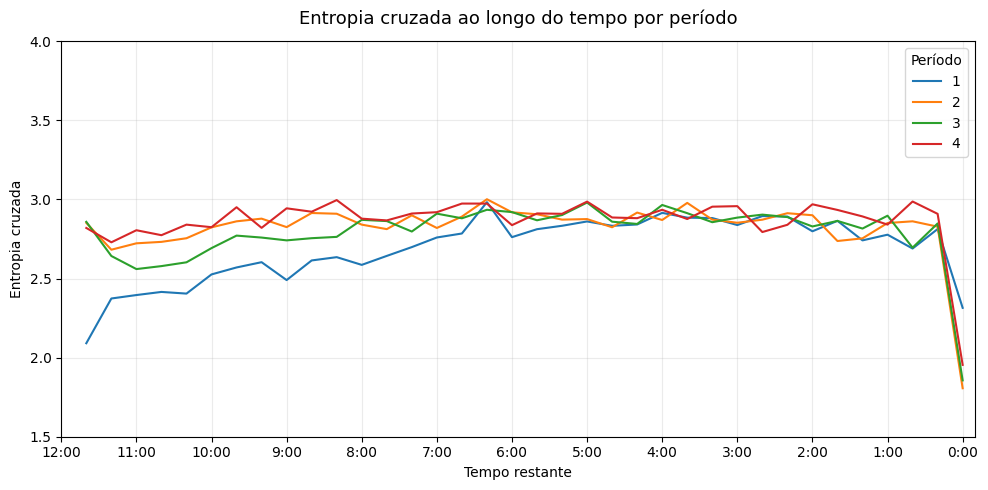

In [39]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "cross_entropy_mean")\
.plot(ax = ax)

ax.set_ylim(1.5, 4)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Entropia cruzada ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Entropia cruzada")
#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



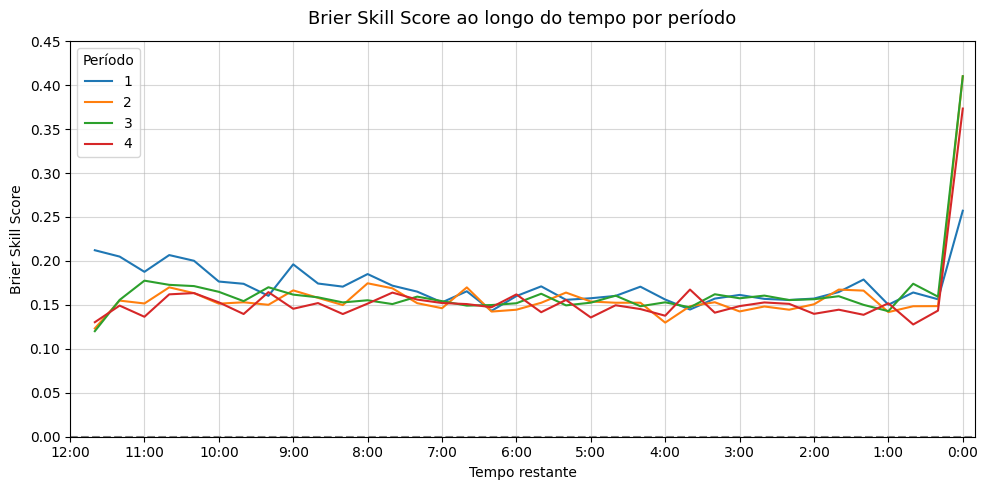

In [40]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "bss_mean")\
.plot(ax = ax)

ax.set_ylim(0, 0.45)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.5)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Brier Skill Score ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Brier Skill Score")
ax.axhline(0, zorder = -3, linestyle = '--', color = 'gray')
plt.tight_layout()



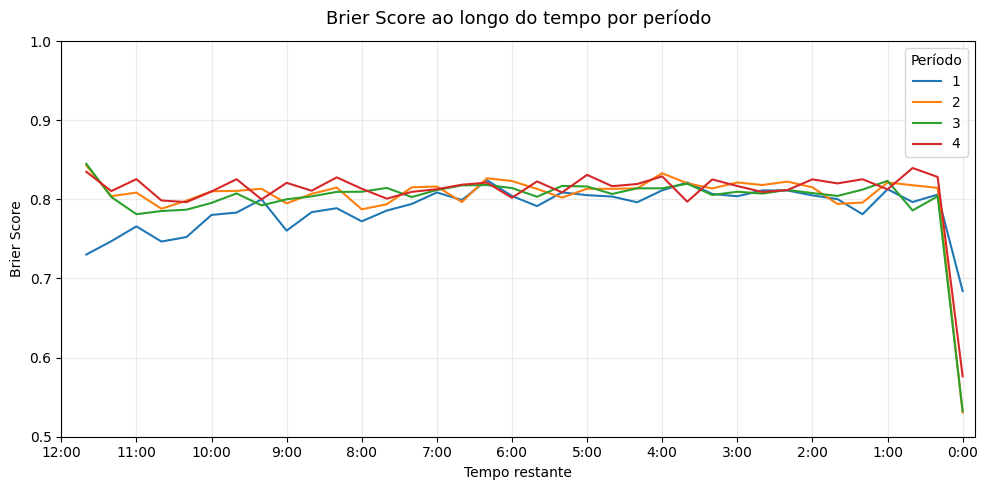

In [41]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "bs_mean")\
.plot(ax = ax)

ax.set_ylim(0.5, 1)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Brier Score ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Brier Score")

# Grade leve para leitura
ax.grid(True, alpha=0.25)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



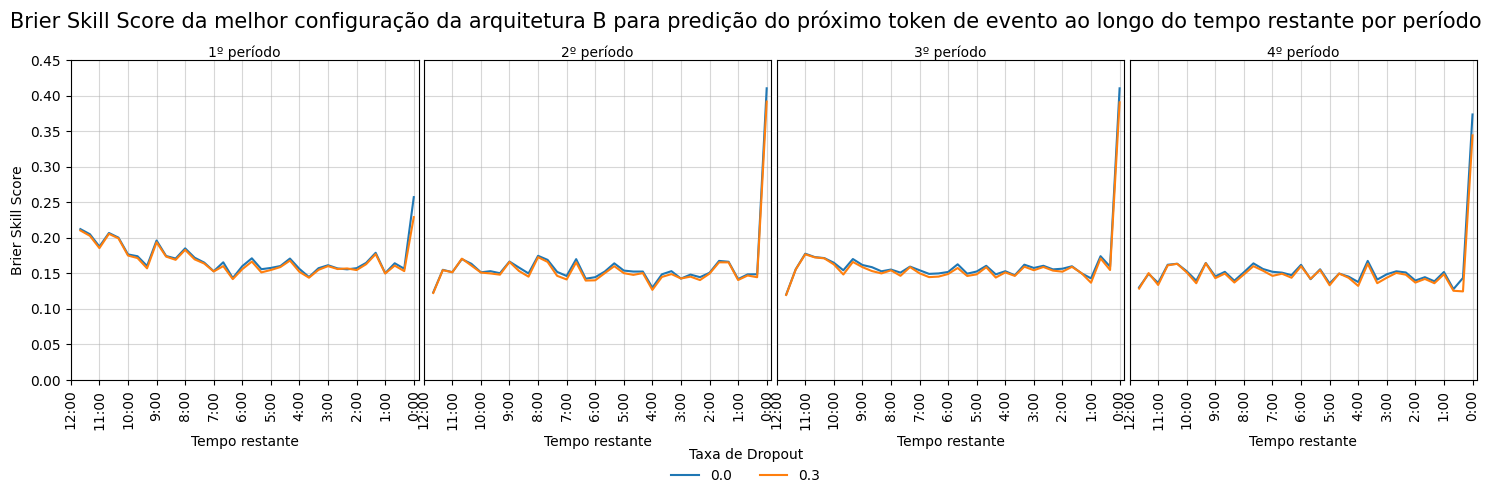

In [18]:
fig, ax = plt.subplots(1, 4, figsize = (15, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "bss_mean")\
    .plot(ax = ax[i], legend=False)

    bounds_y = [0, 0.45]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Brier Skill Score da melhor configuração da arquitetura B para predição do próximo token de evento ao longo do tempo restante por período", fontsize = 15, y = 0.92)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Taxa de Dropout", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

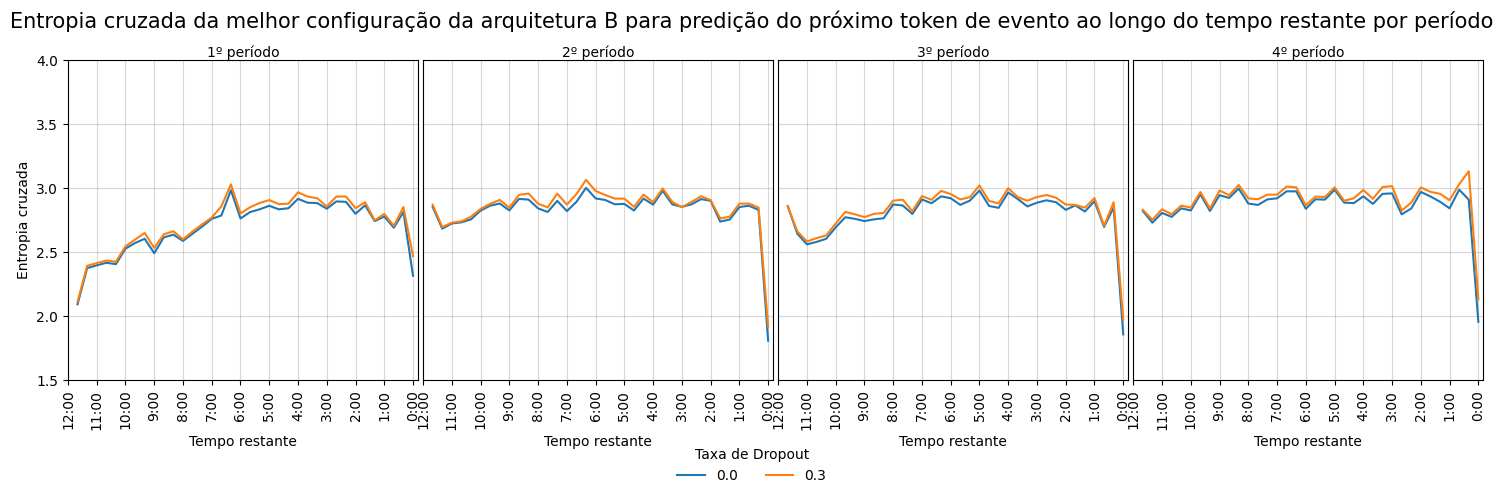

In [20]:
fig, ax = plt.subplots(1, 4, figsize = (15, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "cross_entropy_mean")\
    .plot(ax = ax[i], legend=False)

    bounds_y = [1.5, 4]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.5))    
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Entropia cruzada")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
#fig.suptitle("Entropia cruzada ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
fig.suptitle("Entropia cruzada da melhor configuração da arquitetura B para predição do próximo token de evento ao longo do tempo restante por período", fontsize = 15, y = 0.92)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Taxa de Dropout", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

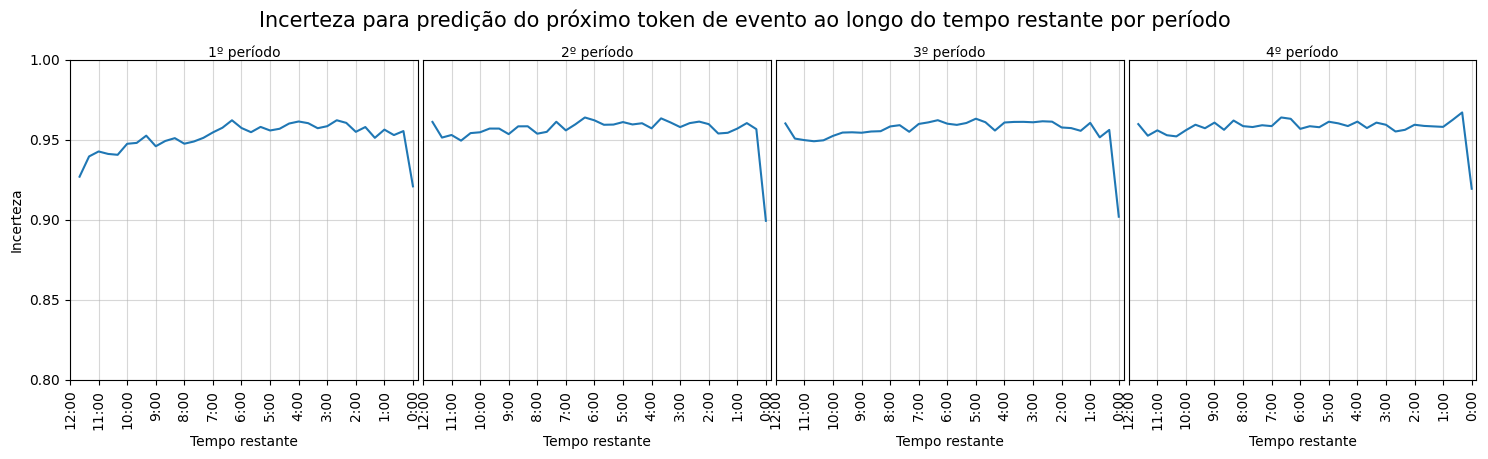

In [22]:
fig, ax = plt.subplots(1, 4, figsize = (15, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "num_layers", values = "uncertainty_caos_mean")\
    .plot(ax = ax[i], legend=False)

    bounds_y = [0.80, 1]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Incerteza")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
#fig.suptitle("Incerteza ao longo do tempo restante por período", fontsize = 15, y = 0.98)
fig.suptitle("Incerteza para predição do próximo token de evento ao longo do tempo restante por período", fontsize = 15, y = 0.92)

# legenda única embaixo
# handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, title = "Taxa de Dropout", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

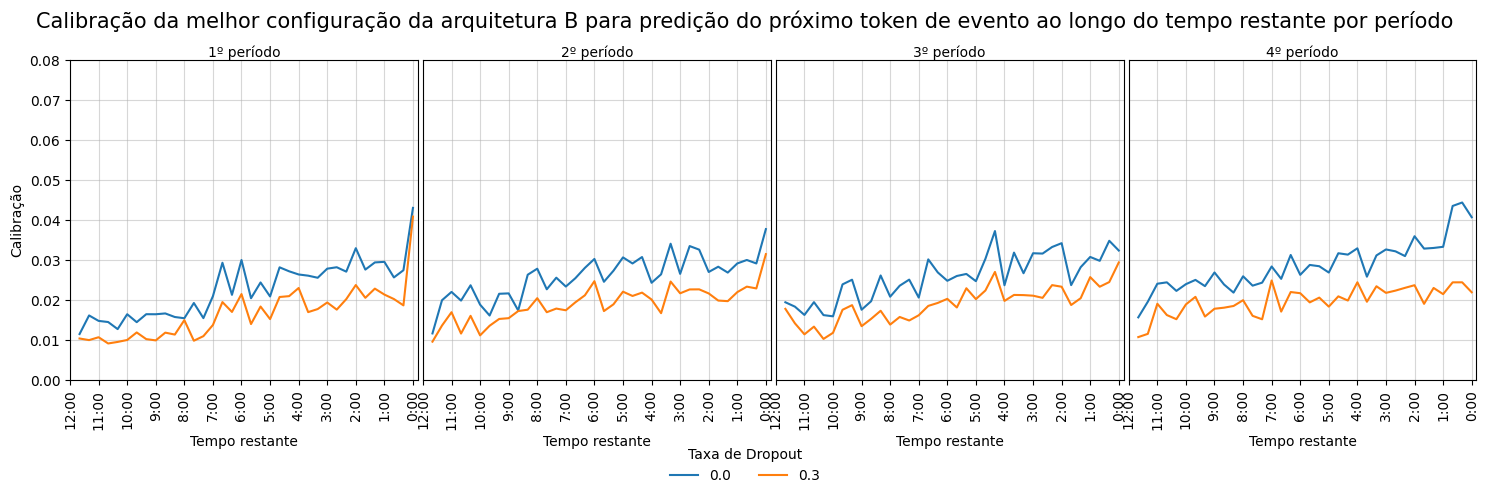

In [24]:
fig, ax = plt.subplots(1, 4, figsize = (15, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "reliability_erro_mean")\
    .plot(ax = ax[i], legend = False)

    ax[i].set_ylim(0.0, 0.08)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Calibração")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)


# legenda única embaixo
fig.suptitle("Calibração da melhor configuração da arquitetura B para predição do próximo token de evento ao longo do tempo restante por período", fontsize = 15, y = 0.92)

#legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Taxa de Dropout", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

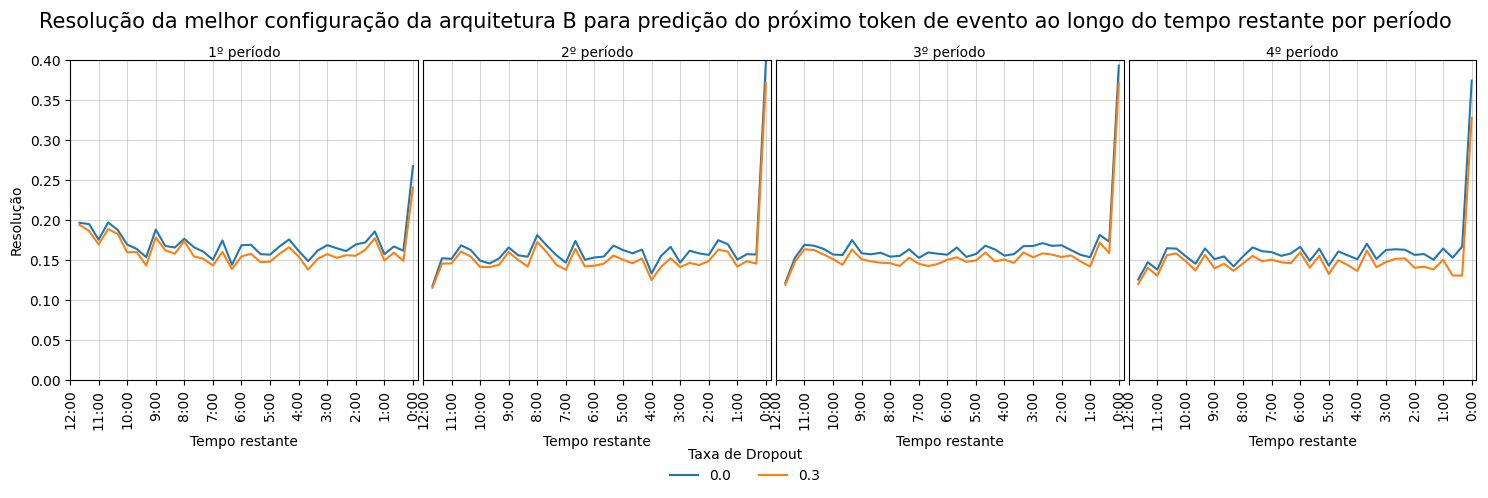

In [25]:
fig, ax = plt.subplots(1, 4, figsize = (15, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "resolution_poder_mean")\
    .plot(ax = ax[i], legend=False)

    bounds_y = [0, 0.4]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Resolução")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Resolução da melhor configuração da arquitetura B para predição do próximo token de evento ao longo do tempo restante por período", fontsize = 15, y = 0.92)

#legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Taxa de Dropout", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

In [26]:
df_resultados3.query("cat_time in ['0-200'] & period == 4")\
.pivot_table(index = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"], columns =  "seasondata", values = "bss")\
.reset_index()

seasondata,period,cat_time,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,201819,201920,202021,202122,202223
0,4,0-200,5,32,1,50,3,0.0,False,0.394067,0.341849,0.329224,0.336070,0.372752
1,4,0-200,5,32,1,50,3,0.0,True,0.372735,0.333189,0.327569,0.331226,0.377172
2,4,0-200,5,32,1,50,3,0.3,False,0.345879,0.327097,0.305261,0.289215,0.334223
3,4,0-200,5,32,1,50,3,0.3,True,0.356978,0.334121,0.312345,0.295063,0.341106
4,4,0-200,5,32,1,50,5,0.0,False,0.385555,0.340574,0.329599,0.309234,0.364691
5,4,0-200,5,32,1,50,5,0.0,True,0.388507,0.325426,0.324170,0.327367,0.367766
6,4,0-200,5,32,1,50,5,0.3,False,0.330898,0.310349,0.286775,0.274293,0.322685
7,4,0-200,5,32,1,50,5,0.3,True,0.336615,0.320400,0.295610,0.276579,0.315324
8,4,0-200,5,32,2,50,3,0.0,False,0.407392,0.363421,0.354261,0.355738,0.385838
9,4,0-200,5,32,2,50,3,0.0,True,0.401236,0.359877,0.354050,0.350824,0.387317


### Arquitetura B fine-tuning

In [11]:
list_decomposition_time = []
list_decomposition_dif = []
list_decomposition_time_dif = []
list_decomposition_season = []

group_variables1 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables2 = ["cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables3 = ["period", "cat_time", "cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables4 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir(models_token_folder) if "NGramModel_ExtraInfo_first46m" in item and ".pth" in item and str_season in item]
    # 1. PREPARAÇÃO DOS DADOS DA TEMPORADA (FORA DO LOOP DE MODELOS)
    df_ = df_token_features.query("season == @season").query("season_split == 'dev'")

    # Processamento temporal feito uma única vez por temporada
    df_ = (df_
            .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))
            .pipe(get_match_splits, num_secs = 200))\
    .assign(cat_time = lambda df: df["cat_time"].astype("str"))\
    .assign(cat_dif = lambda df: df["token_state"] % 9)

    # Conversão eficiente de memória
    dev_tkn1 = torch.from_numpy(np.stack(df_.query("ind_last_2_minutes_game == 0")["token_features"].values)).to(torch.int64)
    dev_num1 = torch.from_numpy(np.stack(df_.query("ind_last_2_minutes_game == 0")["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
    dev_y1 = df_.query("ind_last_2_minutes_game == 0")["target_tokens"].values
    dev_mask1 = torch.tensor(build_logit_mask_ngram_models(df_.query("ind_last_2_minutes_game == 0")), dtype = torch.bool, device = device)

    dev_tkn2 = torch.from_numpy(np.stack(df_.query("ind_last_2_minutes_game == 1")["token_features"].values)).to(torch.int64)
    dev_num2 = torch.from_numpy(np.stack(df_.query("ind_last_2_minutes_game == 1")["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
    dev_y2 = df_.query("ind_last_2_minutes_game == 1")["target_tokens"].values
    dev_mask2 = torch.tensor(build_logit_mask_ngram_models(df_.query("ind_last_2_minutes_game == 1")), dtype = torch.bool, device = device)

    print(season)

    mask_last2 = df_["ind_last_2_minutes_game"].to_numpy() == 1
    mask_first46 = ~mask_last2

    for model_filename in tqdm.tqdm(list_models):

        CONTEXT_SIZE = int(model_filename.split("_context")[1].split("_")[0])
        EMBEDDING_LAYER_SIZE = int(model_filename.split("_embedding")[1].split("_")[0])
        variables_config = int(model_filename.split("_setcovariables")[1].split("_")[0])
        numerical_input_size = len(dict_set_covariables['index'][variables_config])
        num_hidden_neurons = int(model_filename.split("_numneurons")[1].split("_")[0])
        num_layers = int(model_filename.split("_numlayers")[1].split("_")[0])
        dropout_rate = 0 if "nodropout" in model_filename else int(model_filename.split("_dropout")[1].split("_")[0]) / 10
        layer_norm = True if model_filename.split("_layernorm")[1].split("_")[0] == 'True' else False

        index_covariables = dict_set_covariables["index"][variables_config]

        token_model_first46m = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE,
                                                    numerical_input_dim = numerical_input_size, num_hidden_neurons = num_hidden_neurons,
                                                    num_layers = num_layers, activation = nn.GELU, dropout_rate = dropout_rate,
                                                    use_layer_norm = layer_norm)

        token_model_first46m.load_state_dict(torch.load(models_token_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
        token_model_first46m.eval()

        token_model_last2m = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE,
                                                    numerical_input_dim = numerical_input_size, num_hidden_neurons = num_hidden_neurons,
                                                    num_layers = num_layers, activation = nn.GELU, dropout_rate = dropout_rate,
                                                    use_layer_norm = layer_norm)

        model_filename = model_filename.replace("first46m", "last2m")
        token_model_last2m.load_state_dict(torch.load(models_token_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
        token_model_last2m.eval()

        # 2. INFERÊNCIA
        with torch.no_grad():
            # Ajuste condicional para modelos que requerem variáveis numéricas
            output_model1 = token_model_first46m(dev_tkn1[:, -CONTEXT_SIZE:], dev_num1[:, index_covariables])
            output_model2 = token_model_last2m(dev_tkn2[:, -CONTEXT_SIZE:], dev_num2[:, index_covariables])

            output_model1 = output_model1.masked_fill(dev_mask1, -1e9)
            output_model2 = output_model2.masked_fill(dev_mask2, -1e9)

            all_probs1 = torch.softmax(output_model1, dim = 1).cpu().numpy()
            all_probs2 = torch.softmax(output_model2, dim = 1).cpu().numpy()

        #all_probs = np.concat([all_probs1, all_probs2])
        all_probs = np.empty((len(df_), VOCAB_SIZE), dtype = np.float32)
        all_probs[mask_first46] = all_probs1
        all_probs[mask_last2] = all_probs2
        dev_y = df_["target_tokens"].to_numpy()
        #dev_y = np.concat([dev_y1, dev_y2])
       
        # 3. EXTRAÇÃO POR TEMPO
        results_time = []
        for name, group_idx in df_.groupby(["season_split", "period", "cat_time"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True)
            res_df["season_split"] = name[0]
            res_df["period"] = name[1]
            res_df["cat_time"] = name[2]
            results_time.append(res_df)

        df_decomposition_by_time = pd.concat(results_time, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_time = df_decomposition_by_time\
        .groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_time[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_time.append(df_resultados_time)

        # 3. EXTRAÇÃO POR DIF
        results_dif = []
        for name, group_idx in df_.groupby(["season_split", "cat_dif"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True)
            res_df["season_split"] = name[0]
            res_df["cat_dif"] = name[1]
            results_dif.append(res_df)

        df_decomposition_by_dif = pd.concat(results_dif, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_dif = df_decomposition_by_dif\
        .groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_dif[group_variables2 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_dif.append(df_resultados_dif)

        # 3. EXTRAÇÃO POR TIME E DIF
        results_time_dif = []
        for name, group_idx in df_.groupby(["season_split", "period", "cat_time", "cat_dif"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True)
            res_df["season_split"] = name[0]
            res_df["period"] = name[1]
            res_df["cat_time"] = name[2]
            res_df["cat_dif"] = name[3]
            results_time_dif.append(res_df)

        df_decomposition_by_time_dif = pd.concat(results_time_dif, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_time_dif = df_decomposition_by_time_dif\
        .groupby(group_variables3 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_time_dif[group_variables3 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_time_dif.append(df_resultados_time_dif)

        # 4. EXTRAÇÃO POR SPLIT
        results_split = []
        for name, group_idx in df_.groupby(["season_split"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True)
            # Como agrupou por apenas 1 coluna, name pode não ser tupla. Usamos diretamente.
            res_df["season_split"] = name
            results_split.append(res_df)

        df_decomposition_by_split = pd.concat(results_split, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_split = df_decomposition_by_split\
        .groupby(group_variables4 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_split[group_variables4 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_season.append(df_resultados_split)


2018-19


100%|██████████| 32/32 [07:46<00:00, 14.58s/it]


2019-20


100%|██████████| 32/32 [07:26<00:00, 13.97s/it]


2020-21


100%|██████████| 32/32 [06:42<00:00, 12.57s/it]


2021-22


100%|██████████| 32/32 [07:31<00:00, 14.12s/it]


2022-23


100%|██████████| 32/32 [07:12<00:00, 13.52s/it]


In [18]:
models_token_metrics_folder = "G:\Meu Drive\mestrado_final_files\metrics_models\\NGramModel_ExtraInfo_segregated\\"

In [19]:
os.listdir(models_token_metrics_folder)

['murphy_decomposition_by_time.parquet',
 'murphy_decomposition_by_season_split.parquet',
 'murphy_decomposition_by_time_TIME_MODEL.parquet',
 'murphy_decomposition_by_season_split_TIME_MODEL.parquet',
 'murphy_decomposition_by_dif.parquet',
 'murphy_decomposition_by_time_dif.parquet',
 'murphy_decomposition_by_dif_TIME_MODEL.parquet',
 'murphy_decomposition_by_time_dif_TIME_MODEL.parquet',
 'desktop.ini']

In [20]:
df_murphy_decomposition_by_time = pd.concat(list_decomposition_time, ignore_index = True)
df_murphy_decomposition_by_time.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time.parquet", index = False, compression = "zstd")

In [21]:
df_murphy_decomposition_by_dif = pd.concat(list_decomposition_dif, ignore_index = True)
df_murphy_decomposition_by_dif.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_dif.parquet", index = False, compression = "zstd")

In [22]:
df_murphy_decomposition_by_time_dif = pd.concat(list_decomposition_time_dif, ignore_index = True)
df_murphy_decomposition_by_time_dif.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_dif.parquet", index = False, compression = "zstd")

In [23]:
df_murphy_decomposition_by_season_split = pd.concat(list_decomposition_season, ignore_index = True)
df_murphy_decomposition_by_season_split.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split.parquet", index = False, compression = "zstd")

In [23]:
list_num_parametros1 = []
list_num_parametros2 = []
for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir(models_token_folder) if "NGramModel_ExtraInfo_first46m" in item and ".pkl" in item and str_season in item]

    for file in tqdm.tqdm(list_models):
        with open(models_token_folder + file, "rb") as f:
            resultados_modelo = pickle.load(f)

        list_num_parametros1.append((file.replace("results_", ""), resultados_modelo["num_parameters"]))

    list_models = [item for item in os.listdir(models_token_folder) if "NGramModel_ExtraInfo_last2m" in item and ".pkl" in item and str_season in item]
    for file in tqdm.tqdm(list_models):
        with open(models_token_folder + file, "rb") as f:
            resultados_modelo = pickle.load(f)

        list_num_parametros2.append((file.replace("results_", ""), resultados_modelo["num_parameters"]))



100%|██████████| 32/32 [00:00<00:00, 45.26it/s]


In [24]:
df_parameters = pd.DataFrame(list_num_parametros2, columns = ["modelname", "num_parameters"])

In [75]:
df_parameters\
.assign(seasondata = lambda df: df["modelname"].str.split("_").str[3].str.replace("seasondata", "").astype("int"))\
.assign(context_size = lambda df: df["modelname"].str.split("_").str[4].str.replace("context", "").astype("int"))\
.assign(embedding_layer_size = lambda df: df["modelname"].str.split("_").str[5].str.replace("embedding", "").astype("int"))\
.assign(num_layers = lambda df: df["modelname"].str.split("_").str[6].str.replace("numlayers", "").astype("int"))\
.assign(num_hidden_neurons = lambda df: df["modelname"].str.split("_").str[7].str.replace("numneurons", "").astype("int"))\
.assign(dropout_rate = lambda df: df["modelname"].str.split("_").str[8].str.replace("dropout", "").replace("no", 0).astype("int") / 10)\
.assign(layer_norm = lambda df: df["modelname"].str.split("_").str[9].str.replace("layernorm", ""))\
.assign(set_covariables = lambda df: df["modelname"].str.split("_").str[10].str.replace("setcovariables", "").replace("\.pkl", "", regex = True).astype("int"))\
.drop(columns = "modelname")\
.sort_values("num_parameters")\
.drop_duplicates(["context_size", "embedding_layer_size", "num_layers", "num_hidden_neurons", "layer_norm", "set_covariables"])\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "set_covariables"], columns = ["num_layers", "layer_norm"], values = "num_parameters", aggfunc= lambda x: x)\
.reset_index()

num_layers context_size embedding_layer_size num_hidden_neurons  \
layer_norm                                                        
0                     5                   32                 50   
1                     5                   32                 50   
2                     5                   64                 50   
3                     5                   64                 50   

num_layers set_covariables      3             5         
layer_norm                  False   True  False   True  
0                        1  63833  64385  68933  69685  
1                        2  65033  65633  70133  70933  
2                        1  91065  91937  96165  97237  
3                        2  92265  93185  97365  98485

In [76]:
models_token_metrics_folder

'G:\\Meu Drive\\mestrado_final_files\\metrics_models\\NGramModel_ExtraInfo_segregated\\'

In [27]:
df_murphy_decomposition_by_season_split = pd.read_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split.parquet")

In [28]:
group_variables1 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

In [29]:
df_resultados1 = df_murphy_decomposition_by_season_split\
.groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
.merge(df_murphy_decomposition_by_season_split[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
.assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

df_resultados2 = df_resultados1\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [30]:
df_resultados2\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1   2.7812 (0.0178) [2]  2.7905 (0.0204) [10]   
1                          2   2.7780 (0.0203) [1]   2.7861 (0.0205) [6]   
2                          1  2.7917 (0.0171) [12]   2.7903 (0.0200) [9]   
3                          2   2.7837 (0.0182) [4]   2.7863 (0.0210) [7]   
4                          1   2.7844 (0.0196) [5]  2.7935 (0.0178) [14]   
5                          2   2.7833 (0.0193) [3]   2.7892 (0.0194) [8]   
6                          1  2.7933 (0.0189) [13]  2.7939 (0.0213) [16]   
7                          2  2.7937 (0.0181) [15]  2.7906 (0.0208) [11]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.8211 (0.0179) [24]  2.8083 (0.0201) [19]  
1             2.8162 (0.0206) [22]  2.8042 (0.0199) [18]  
2             2.8588 (0.0218) [30]  2.8618 (0.0214) [32]  
3             2.8549 (0.0203) [26]  2.8553 (0.0172) [27]  
4             2.8209 (0.0179) [23]  2.8094 (0.0223) [20]  
5             2.8151 (0.0198) [21]  2.8032 (0.0183) [17]  
6             2.8565 (0.0165) [28]  2.8600 (0.0238) [31]  
7             2.8485 (0.0212) [25]  2.8575 (0.0186) [29]

In [31]:
df_resultados2\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", 'set_covariables'], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1   0.1726 (0.0025) [3]  0.1716 (0.0026) [12]   
1                          2   0.1730 (0.0028) [1]   0.1723 (0.0025) [5]   
2                          1   0.1720 (0.0024) [7]  0.1718 (0.0025) [10]   
3                          2   0.1726 (0.0027) [2]   0.1720 (0.0028) [8]   
4                          1   0.1721 (0.0024) [6]  0.1712 (0.0021) [16]   
5                          2   0.1725 (0.0027) [4]   0.1719 (0.0026) [9]   
6                          1  0.1714 (0.0029) [15]  0.1715 (0.0027) [14]   
7                          2  0.1716 (0.0025) [13]  0.1717 (0.0026) [11]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             0.1690 (0.0029) [23]  0.1702 (0.0030) [19]  
1             0.1693 (0.0030) [22]  0.1707 (0.0031) [18]  
2             0.1643 (0.0030) [28]  0.1638 (0.0032) [32]  
3             0.1645 (0.0020) [26]  0.1643 (0.0026) [29]  
4             0.1689 (0.0029) [24]  0.1701 (0.0028) [20]  
5             0.1696 (0.0029) [21]  0.1709 (0.0028) [17]  
6             0.1644 (0.0025) [27]  0.1641 (0.0035) [31]  
7             0.1648 (0.0025) [25]  0.1642 (0.0024) [30]

In [82]:
df_resultados2\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(index = lambda df: df["index"] + 1)\
.groupby(["embedding_layer_size"], as_index = False)["index"].describe()

# embedding_layer_size
# 0	32	16.0	15.125	10.436315	1.0	6.75	13.0	24.5	31.0
# 1	64	16.0	17.875	8.301606	3.0	12.75	17.5	23.5	32.0

# num_layers
# 0	3	16.0	13.5	8.041559	1.0	 6.5	15.5	20.25	24.0
# 1	5	16.0	19.5	9.899495	4.0	11.5	21.0	28.25	32.0

# set_covariables
# 0	1	16.0	17.6875	9.775607	2.0	9.75	18.0	25.00	32.0
# 1	2	16.0	15.3125	9.126655	1.0	7.75	15.0	22.75	29.0

# dropout_rate
# 0	0.0	16.0	 8.5625	4.871259	 1.0	 4.75	 8.5	12.25	17.0
# 1	0.3	16.0	24.4375	4.871259	16.0	20.75	24.5	28.25	32.0

# layer_norm
# 0	False	16.0	15.3125	10.543363	1.0	 4.75	17.0	24.25	30.0
# 1	True	16.0	17.6875	 8.227748	7.0	10.75	16.5	21.75	32.0

# layer_norm, dropout_rate
# 0	False	0.0	8.0	 5.750	4.464143	 1.0	 2.75	 4.5	 7.50	13.0
# 1	False	0.3	8.0	24.875	3.044316	21.0	22.75	24.5	26.50	30.0
# 2	True	0.0	8.0	11.375	3.583195	 7.0	 8.75	10.5	14.25	17.0
# 3	True	0.3	8.0	24.000	6.414270	16.0	18.75	23.5	29.50	32.0


,embedding_layer_size,count,mean,std,min,25%,50%,75%,max
0,32,16.0,15.125,10.436315,1.0,6.75,13.0,24.5,31.0
1,64,16.0,17.875,8.301606,3.0,12.75,17.5,23.5,32.0


In [83]:
df_resultados2\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(index = lambda df: df["index"] + 1)\
.groupby(["layer_norm", "dropout_rate"], as_index = False)["index"].describe()

# embedding_layer_size
# 0	32	16.0	14.875	10.663802	1.0	 6.50	12.0	24.25	32.0
# 1	64	16.0	18.125	7.906748	4.0	12.75	18.0	23.75	31.0

# num_layers
# 0	3	16.0	13.25	7.707140	1.0	 6.75	13.5	19.50	24.0
# 1	5	16.0	19.75	9.996666	3.0	10.75	22.5	28.25	32.0

# set_covariables
# 0	1	16.0	17.9375	9.419616	2.0	9.75	18.5	24.75	32.0
# 1	2	16.0	15.0625	9.419616	1.0	7.75	13.5	22.75	30.0

#dropout_rate
# 0	0.0	16.0	9.125	5.702339	 1.0	 4.75	 8.5	12.75	20.0
# 1	0.3	16.0	23.875	5.772059	13.0	20.50	24.5	28.25	32.0

# layer_norm
# 0	False	16.0	15.25	10.298867	1.0	 4.75	18.5	24.25	28.0
# 1	True	16.0	17.75	 8.512736	7.0	11.50	16.0	22.25	32.0

# layer_norm, dropout_rate
# 0	False	0.0	8.0	 6.00	5.070926	 1.0	 2.75	 4.5	 7.25	16.0
# 1	False	0.3	8.0	24.50	2.449490	21.0	22.75	24.5	26.25	28.0
# 2	True	0.0	8.0	12.25	4.652188	 7.0	 8.75	11.0	15.50	20.0
# 3	True	0.3	8.0	23.25	8.031189	13.0	17.00	24.0	30.25	32.0



,layer_norm,dropout_rate,count,mean,std,min,25%,50%,75%,max
0,False,0.0,8.0,6.00,5.070926,1.0,2.75,4.5,7.25,16.0
1,False,0.3,8.0,24.50,2.449490,21.0,22.75,24.5,26.25,28.0
2,True,0.0,8.0,12.25,4.652188,7.0,8.75,11.0,15.50,20.0
3,True,0.3,8.0,23.25,8.031189,13.0,17.00,24.0,30.25,32.0


In [84]:
df_resultados1\
.pivot_table(index = group_variables1, columns =  "seasondata", values = "bss")\
.reset_index()

seasondata,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,201819,201920,202021,202122,202223
0,5,32,1,50,3,0.0,False,0.169503,0.175526,0.173460,0.174111,0.170313
1,5,32,1,50,3,0.0,True,0.167847,0.174373,0.172378,0.173178,0.169454
2,5,32,1,50,3,0.3,False,0.166142,0.172987,0.170282,0.171257,0.167100
3,5,32,1,50,3,0.3,True,0.167431,0.174303,0.171481,0.172324,0.168376
4,5,32,1,50,5,0.0,False,0.168727,0.175368,0.172960,0.173349,0.169764
5,5,32,1,50,5,0.0,True,0.168455,0.174625,0.172070,0.173030,0.169039
6,5,32,1,50,5,0.3,False,0.161608,0.169818,0.167174,0.166961,0.163833
7,5,32,1,50,5,0.3,True,0.161304,0.168934,0.165937,0.166211,0.162088
8,5,32,2,50,3,0.0,False,0.169708,0.176024,0.174099,0.174940,0.170462
9,5,32,2,50,3,0.0,True,0.168810,0.174838,0.172250,0.173566,0.169302


In [85]:
models_token_metrics_folder

'G:\\Meu Drive\\mestrado_final_files\\metrics_models\\NGramModel_ExtraInfo_segregated\\'

In [86]:
os.listdir(models_token_metrics_folder)

['murphy_decomposition_by_time.parquet',
 'murphy_decomposition_by_season_split.parquet',
 'murphy_decomposition_by_time_TIME_MODEL.parquet',
 'murphy_decomposition_by_season_split_TIME_MODEL.parquet',
 'desktop.ini']

In [32]:
df_murphy_decomposition_by_time = pd.read_parquet(models_token_metrics_folder + "murphy_decomposition_by_time.parquet")

In [33]:
group_variables2 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

<Axes: xlabel='cat_time'>

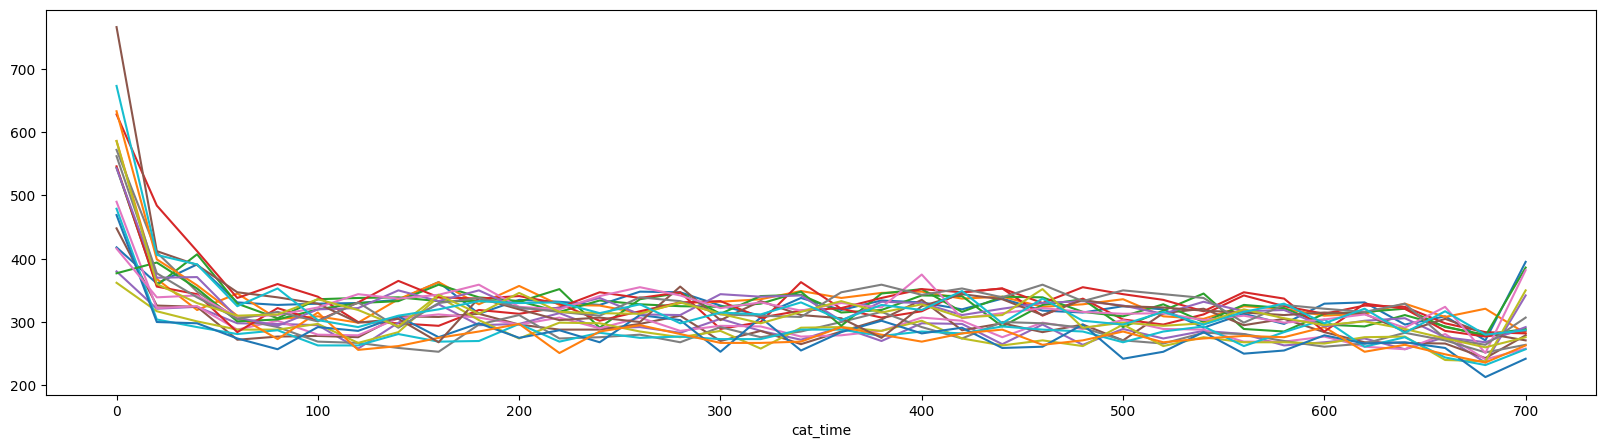

In [34]:
df_murphy_decomposition_by_time\
.groupby(["seasondata", "layer_norm", "dropout_rate", "num_layers", "num_hidden_neurons", "set_covariables", "embedding_layer_size", "context_size", "period", "cat_time"], as_index = False, dropna = False)["frequencia"].sum()\
.query("period <= 4")\
[["seasondata", "period", "cat_time", "frequencia"]].drop_duplicates()\
.assign(cat_time = lambda df: df["cat_time"].str.split("-").str[0].astype("int") / 10)\
.pivot_table(index = ["cat_time"], columns = ["seasondata", "period"], values = "frequencia")\
.plot(figsize = (20, 5), legend = False)

In [90]:
df_murphy_decomposition_by_time\
.groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()

,period,cat_time,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,seasondata,reliability_erro,resolution_poder,uncertainty_caos
0,1,0-200,5,32,1,50,3,0.0,False,201819,0.035714,0.270746,0.916222
1,1,0-200,5,32,1,50,3,0.0,False,201920,0.038711,0.261812,0.927091
2,1,0-200,5,32,1,50,3,0.0,False,202021,0.049895,0.268146,0.921187
3,1,0-200,5,32,1,50,3,0.0,False,202122,0.038688,0.244332,0.913649
4,1,0-200,5,32,1,50,3,0.0,False,202223,0.038349,0.277420,0.926521
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25435,5,800-1000,5,64,2,50,5,0.3,True,201819,0.074285,0.066012,0.938017
25436,5,800-1000,5,64,2,50,5,0.3,True,201920,0.048858,0.070159,0.953333
25437,5,800-1000,5,64,2,50,5,0.3,True,202021,0.467579,0.340000,0.720000
25438,5,800-1000,5,64,2,50,5,0.3,True,202122,0.206034,0.289116,0.846939


In [35]:
df_resultados3 = df_murphy_decomposition_by_time\
.groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
.merge(df_murphy_decomposition_by_time[group_variables2 + ["seasondata", "brier_score_multinomial", "cross_entropy"]].drop_duplicates(), how = "left")\
.assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

In [37]:
df_resultados4 = df_resultados3\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

In [39]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1   2.0274 (0.1354) [8]  2.0584 (0.0927) [11]   
1                          2   1.9540 (0.0875) [1]   1.9714 (0.1029) [2]   
2                          1  2.0902 (0.1363) [18]  2.0647 (0.1251) [14]   
3                          2   1.9743 (0.1334) [3]   1.9970 (0.1020) [6]   
4                          1   2.0444 (0.0992) [9]  2.0648 (0.1189) [15]   
5                          2   1.9853 (0.1284) [4]   1.9968 (0.1115) [5]   
6                          1  2.0797 (0.1276) [17]  2.0775 (0.1016) [16]   
7                          2  2.0489 (0.1361) [10]   2.0031 (0.1167) [7]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.2195 (0.1175) [26]  2.1811 (0.1063) [22]  
1             2.1292 (0.1176) [20]  2.0604 (0.1068) [12]  
2             2.3096 (0.1243) [32]  2.2894 (0.1164) [31]  
3             2.2287 (0.1290) [27]  2.2038 (0.1190) [23]  
4             2.2309 (0.1235) [28]  2.1685 (0.0978) [21]  
5             2.1045 (0.1159) [19]  2.0634 (0.1219) [13]  
6             2.2773 (0.1143) [29]  2.2892 (0.1126) [30]  
7             2.2096 (0.1183) [25]  2.2080 (0.1109) [24]

In [40]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   
4                       5                   64                 50          3   
5                       5                   64                 50          3   
6                       5                   64                 50          5   
7                       5                   64                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          1  0.3547 (0.0275) [11]  0.3483 (0.0243) [12]   
1                          2   0.3733 (0.0228) [1]   0.3706 (0.0223) [2]   
2                          1  0.3459 (0.0298) [17]  0.3466 (0.0296) [15]   
3                          2   0.3688 (0.0209) [4]   0.3663 (0.0163) [6]   
4                          1  0.3483 (0.0268) [13]  0.3427 (0.0261) [19]   
5                          2   0.3679 (0.0222) [5]   0.3647 (0.0237) [7]   
6                          1  0.3419 (0.0255) [20]  0.3459 (0.0226) [16]   
7                          2   0.3595 (0.0254) [8]   0.3695 (0.0290) [3]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             0.3203 (0.0228) [27]  0.3279 (0.0243) [26]  
1             0.3439 (0.0247) [18]  0.3562 (0.0234) [10]  
2             0.3050 (0.0239) [32]  0.3089 (0.0232) [30]  
3             0.3307 (0.0279) [24]  0.3348 (0.0268) [21]  
4             0.3186 (0.0236) [28]  0.3279 (0.0219) [25]  
5             0.3470 (0.0235) [14]   0.3565 (0.0270) [9]  
6             0.3124 (0.0211) [29]  0.3077 (0.0225) [31]  
7             0.3335 (0.0250) [23]  0.3336 (0.0249) [22]

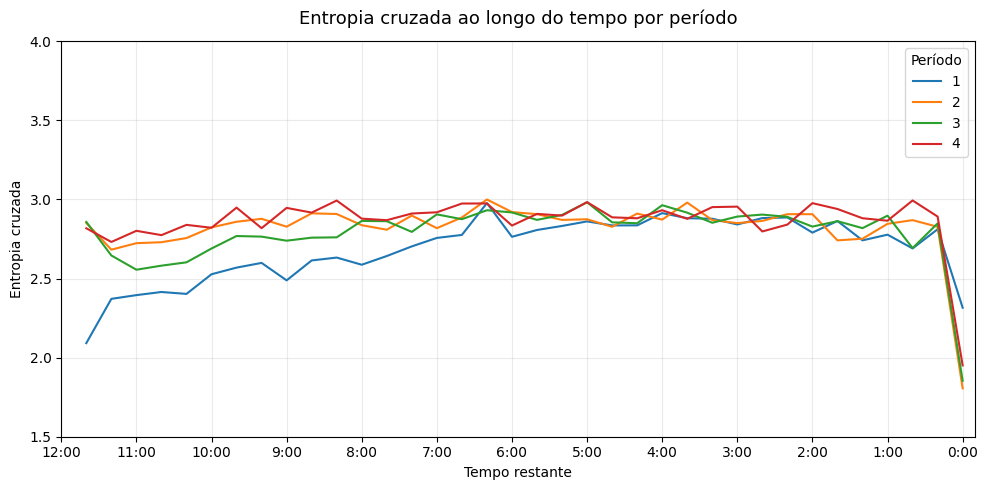

In [95]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "cross_entropy_mean")\
.plot(ax = ax)

ax.set_ylim(1.5, 4)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Entropia cruzada ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Entropia cruzada")
#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



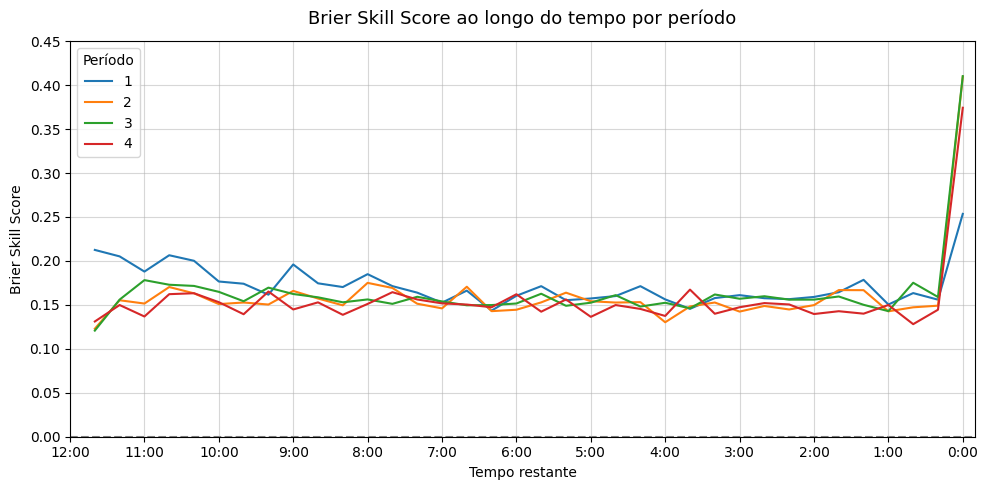

In [96]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "bss_mean")\
.plot(ax = ax)

ax.set_ylim(0, 0.45)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.5)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Brier Skill Score ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Brier Skill Score")
ax.axhline(0, zorder = -3, linestyle = '--', color = 'gray')
plt.tight_layout()



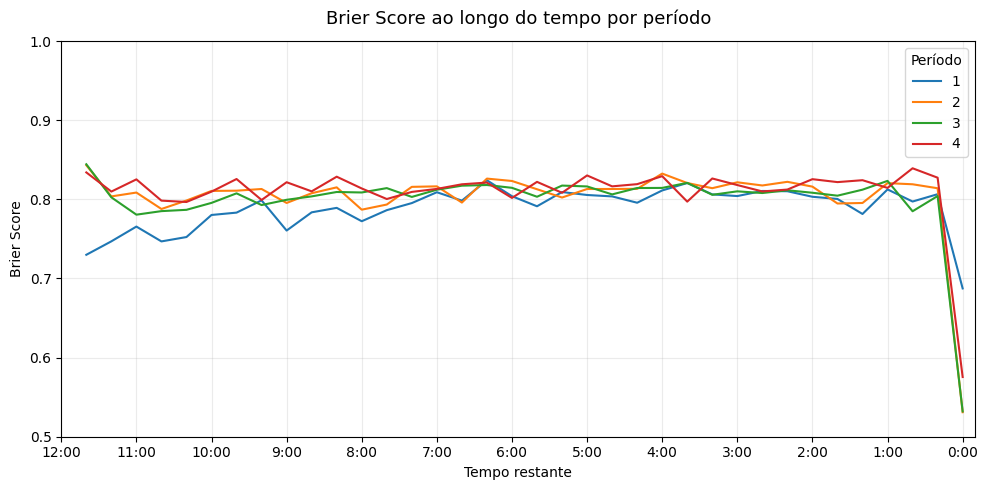

In [97]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "bs_mean")\
.plot(ax = ax)

ax.set_ylim(0.5, 1)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Brier Score ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Brier Score")

# Grade leve para leitura
ax.grid(True, alpha=0.25)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



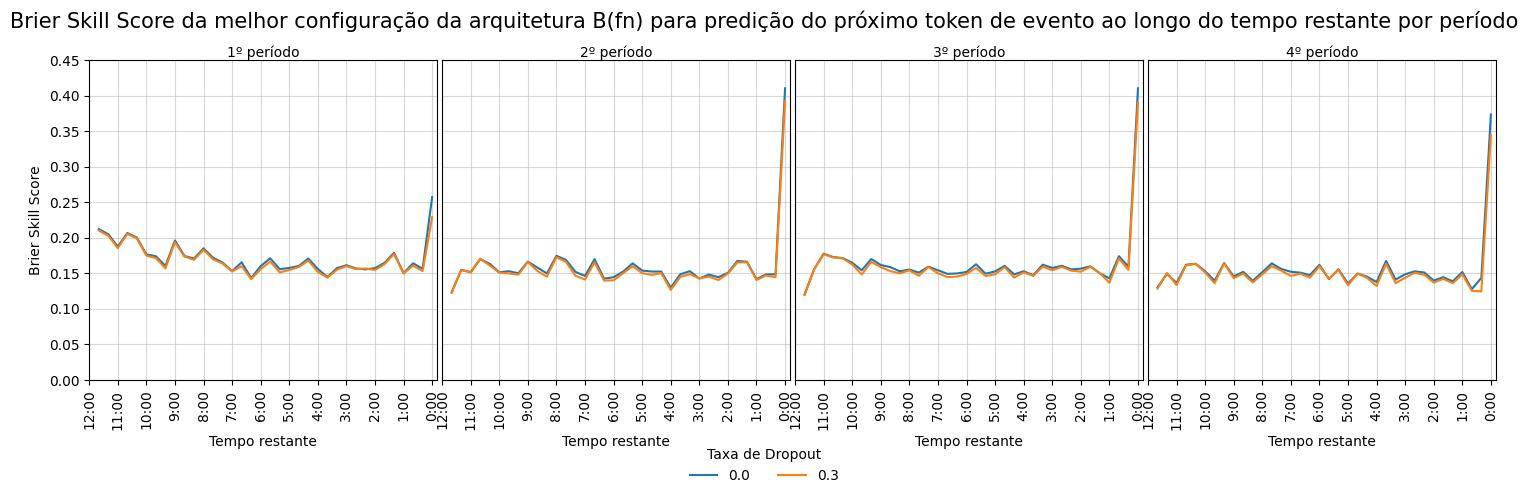

In [44]:
fig, ax = plt.subplots(1, 4, figsize = (15, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & layer_norm == 0 & set_covariables == 2 & num_layers == 3")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "bss_mean")\
    .plot(ax = ax[i], legend=False)

    bounds_y = [0, 0.45]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Brier Skill Score da melhor configuração da arquitetura B(fn) para predição do próximo token de evento ao longo do tempo restante por período", fontsize = 15, y = 0.92)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Taxa de Dropout", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

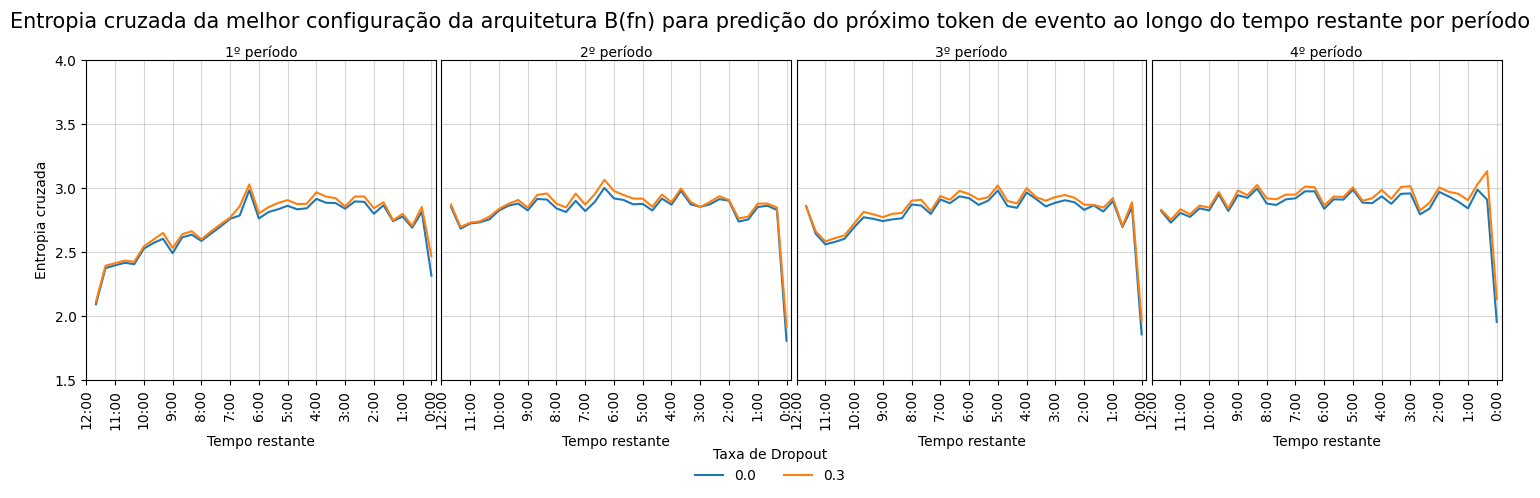

In [50]:
fig, ax = plt.subplots(1, 4, figsize = (15, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "cross_entropy_mean")\
    .plot(ax = ax[i], legend = False)

    bounds_y = [1.5, 4]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.5))    
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Entropia cruzada")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
#fig.suptitle("Entropia cruzada ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
fig.suptitle("Entropia cruzada da melhor configuração da arquitetura B(fn) para predição do próximo token de evento ao longo do tempo restante por período", fontsize = 15, y = 0.92)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Taxa de Dropout", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

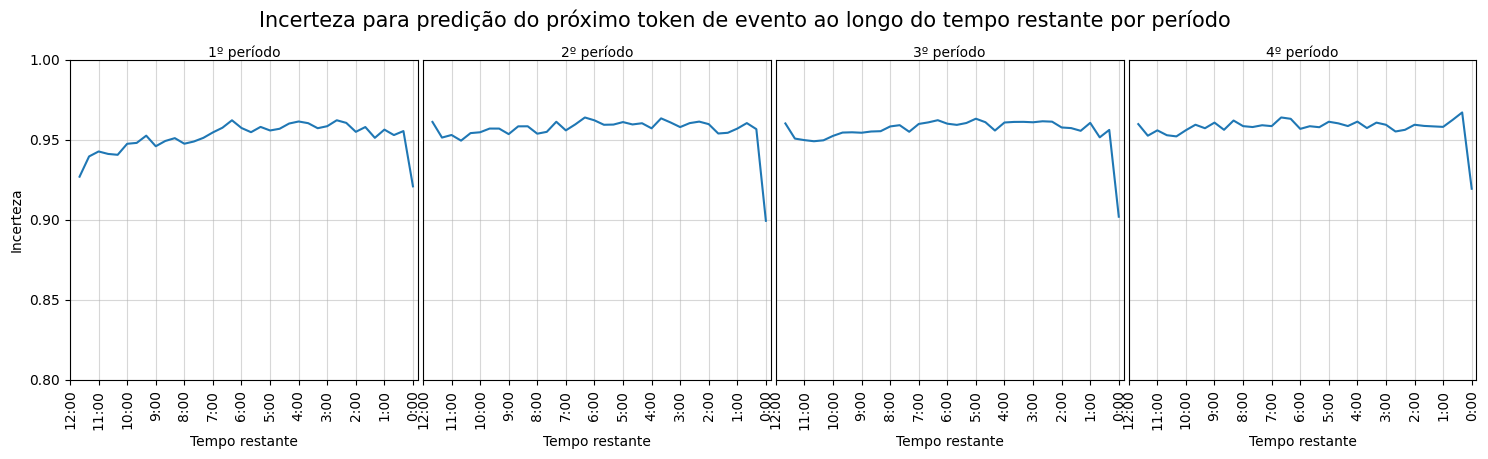

In [52]:
fig, ax = plt.subplots(1, 4, figsize = (15, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2 & num_layers == 3")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "num_layers", values = "uncertainty_caos_mean")\
    .plot(ax = ax[i], legend = False)

    bounds_y = [0.80, 1]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Incerteza")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
#fig.suptitle("Incerteza ao longo do tempo restante por período", fontsize = 15, y = 0.98)
fig.suptitle("Incerteza para predição do próximo token de evento ao longo do tempo restante por período", fontsize = 15, y = 0.92)

# legenda única embaixo
# handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, title = "Taxa de Dropout", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

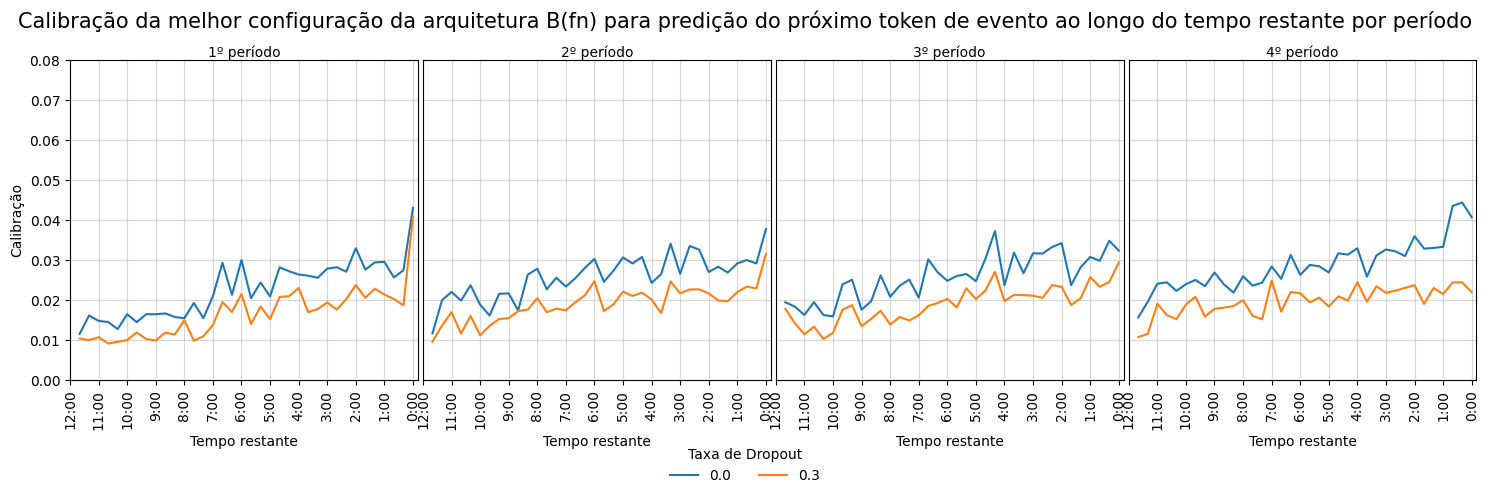

In [53]:
fig, ax = plt.subplots(1, 4, figsize = (15, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "reliability_erro_mean")\
    .plot(ax = ax[i], legend=False)

    ax[i].set_ylim(0.0, 0.08)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Calibração")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)


# legenda única embaixo
fig.suptitle("Calibração da melhor configuração da arquitetura B(fn) para predição do próximo token de evento ao longo do tempo restante por período", fontsize = 15, y = 0.92)

#legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Taxa de Dropout", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

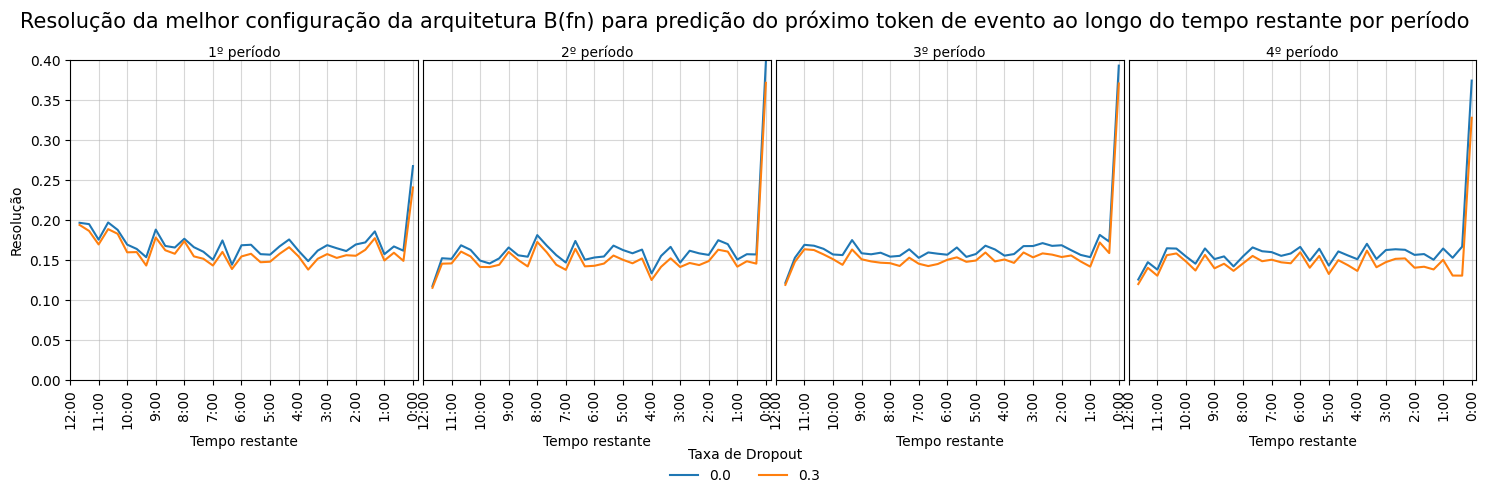

In [54]:
fig, ax = plt.subplots(1, 4, figsize = (15, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & set_covariables == 2")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "resolution_poder_mean")\
    .plot(ax = ax[i], legend = False)

    bounds_y = [0, 0.4]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Resolução")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Resolução da melhor configuração da arquitetura B(fn) para predição do próximo token de evento ao longo do tempo restante por período", fontsize = 15, y = 0.92)

#legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Taxa de Dropout", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

In [105]:
df_resultados3.query("cat_time in ['0-200'] & period == 4")\
.pivot_table(index = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"], columns =  "seasondata", values = "bss")\
.reset_index()

seasondata,period,cat_time,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,201819,201920,202021,202122,202223
0,4,0-200,5,32,1,50,3,0.0,False,0.396716,0.341195,0.331085,0.339677,0.374658
1,4,0-200,5,32,1,50,3,0.0,True,0.371921,0.338505,0.322697,0.327515,0.374777
2,4,0-200,5,32,1,50,3,0.3,False,0.349044,0.326315,0.308473,0.292112,0.337207
3,4,0-200,5,32,1,50,3,0.3,True,0.362444,0.333120,0.317127,0.300890,0.349349
4,4,0-200,5,32,1,50,5,0.0,False,0.386110,0.354700,0.334193,0.314121,0.373192
5,4,0-200,5,32,1,50,5,0.0,True,0.376179,0.330041,0.330726,0.332740,0.364810
6,4,0-200,5,32,1,50,5,0.3,False,0.332199,0.316463,0.291009,0.275346,0.330046
7,4,0-200,5,32,1,50,5,0.3,True,0.339681,0.323943,0.296328,0.284117,0.324273
8,4,0-200,5,32,2,50,3,0.0,False,0.406508,0.361516,0.357280,0.353916,0.392105
9,4,0-200,5,32,2,50,3,0.0,True,0.401736,0.354720,0.348221,0.351348,0.386425
